## Marginal similarity evaluation

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import wasserstein_distance

In [7]:
# Root folders
EXPERIMENTS_ROOT = Path("/data/shared/fsibilla/clean_code/Q0/experiments")
OUTPUT_DIR = Path("/data/shared/fsibilla/clean_code/Q0/fidelity/lka_micron")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Models to scan
MODELS = ["cNF", "NF", 
          "TVAE", "CTGAN"]

# Seeds available
SEEDS = [1, 2, 3, 4, 5]

# Dataset subfolder
DATASET_NAME = "lka_micron"

# Variables for marginal comparison
TARGET_COLS = [
    'vita_rae_mcg',
    'folate_mcg', 'vitb12_mcg', 'fe_mg', 'zn_mg',
    'avg_adult_education', 'log_exp'
]

ADM1_COL = "adm1name"

# Synthetic filename (always seed-specific)
SYN_FILENAME = "synthetic_pool.csv"

# Default real filename for models whose training set depends on seed
REAL_FILENAME_TEMPLATE = "full_lka_cleaned_used_for_training_seed{seed}.csv"

# For NF and cNF, the real/training set is fixed across seeds.
# Put here the exact filename that exists in each seed folder or in the results folder.
# If the same file is duplicated inside each seed folder, this code will use seed_1 by default.
FIXED_REAL_MODELS = {"NF", "cNF"}

# First attempt for fixed-real models:
#   /.../<model>/eth_micron/results/fixed_real_filename
FIXED_REAL_FILENAME = "full_lka_cleaned_used_for_training.csv"

OUTPUT_CSV = OUTPUT_DIR / "emd_gen_true.csv"

In [8]:
REFERENCE_REAL_MODEL = "TVAE"   # model from which to read the real/training files
FIXED_REAL_MODELS = {"NF", "cNF"}

def get_real_path(model: str, seed: int):
    """
    Return the correct real/training-set path for a given model and seed.

    Rules:
    - TVAE, CTGAN: use their own seed-specific real file
    - NF, cNF: use the real file from REFERENCE_REAL_MODEL for the same seed
      because the training data are identical across models
    """
    if model in FIXED_REAL_MODELS:
        real_path = (
            EXPERIMENTS_ROOT
            / REFERENCE_REAL_MODEL
            / DATASET_NAME
            / "results"
            / f"seed_{seed}"
            / REAL_FILENAME_TEMPLATE.format(seed=seed)
        )
    else:
        real_path = (
            EXPERIMENTS_ROOT
            / model
            / DATASET_NAME
            / "results"
            / f"seed_{seed}"
            / REAL_FILENAME_TEMPLATE.format(seed=seed)
        )

    if not real_path.exists():
        raise FileNotFoundError(
            f"Real training file not found for model={model}, seed={seed}: {real_path}"
        )

    return real_path

In [9]:
def load_real_and_synth(model: str, seed: int):
    """
    Load real and synthetic data for one model and one seed.
    """
    seed_dir = EXPERIMENTS_ROOT / model / DATASET_NAME / "results" / f"seed_{seed}"
    
    syn_path = seed_dir / SYN_FILENAME
    real_path = get_real_path(model=model, seed=seed)
    
    if not syn_path.exists():
        raise FileNotFoundError(f"Synthetic file not found: {syn_path}")
    
    syn_df = pd.read_csv(syn_path)
    real_df = pd.read_csv(real_path)
    
    needed_cols = TARGET_COLS + [ADM1_COL]
    
    missing_syn = [c for c in needed_cols if c not in syn_df.columns]
    missing_real = [c for c in needed_cols if c not in real_df.columns]
    
    if missing_syn:
        raise ValueError(f"[{model} seed {seed}] Missing columns in synthetic data: {missing_syn}")
    if missing_real:
        raise ValueError(f"[{model} seed {seed}] Missing columns in real data: {missing_real}")
    
    syn_df = syn_df[needed_cols].copy()
    real_df = real_df[needed_cols].copy()
    
    # Type safety
    syn_df[ADM1_COL] = syn_df[ADM1_COL].astype(str)
    real_df[ADM1_COL] = real_df[ADM1_COL].astype(str)
    
    for col in TARGET_COLS:
        syn_df[col] = pd.to_numeric(syn_df[col], errors="coerce")
        real_df[col] = pd.to_numeric(real_df[col], errors="coerce")
    
    return real_df, syn_df

In [10]:
def compute_emd_by_adm1(real_df: pd.DataFrame, syn_df: pd.DataFrame, model: str, seed: int):
    """
    Compute unscaled EMD (Wasserstein-1 distance) between real and synthetic
    marginals for each variable, separately within each adm1.
    
    Returns a dataframe with columns:
    model, seed, adm1, variable, emd_distance
    """
    results = []
    
    all_adm1 = sorted(
        set(real_df[ADM1_COL].dropna().unique()).intersection(
            set(syn_df[ADM1_COL].dropna().unique())
        )
    )
    
    for adm1 in all_adm1:
        real_adm = real_df.loc[real_df[ADM1_COL] == adm1]
        syn_adm = syn_df.loc[syn_df[ADM1_COL] == adm1]
        
        for var in TARGET_COLS:
            x_real = real_adm[var].dropna().to_numpy()
            x_syn = syn_adm[var].dropna().to_numpy()
            
            if len(x_real) == 0 or len(x_syn) == 0:
                emd = np.nan
            else:
                emd = wasserstein_distance(x_real, x_syn)
            
            results.append({
                "model": model,
                "seed": seed,
                "adm1": adm1,
                "variable": var,
                "emd_distance": emd
            })
    
    return pd.DataFrame(results)

In [11]:
all_results = []

for model in MODELS:
    for seed in SEEDS:
        print(f"Processing model={model}, seed={seed} ...")
        real_df, syn_df = load_real_and_synth(model=model, seed=seed)
        emd_df = compute_emd_by_adm1(
            real_df=real_df,
            syn_df=syn_df,
            model=model,
            seed=seed
        )
        all_results.append(emd_df)

emd_results = pd.concat(all_results, ignore_index=True)

print("\nDone.")
print(f"Rows: {len(emd_results)}")
emd_results.head()

Processing model=cNF, seed=1 ...
Processing model=cNF, seed=2 ...
Processing model=cNF, seed=3 ...
Processing model=cNF, seed=4 ...
Processing model=cNF, seed=5 ...
Processing model=NF, seed=1 ...
Processing model=NF, seed=2 ...
Processing model=NF, seed=3 ...
Processing model=NF, seed=4 ...
Processing model=NF, seed=5 ...
Processing model=TVAE, seed=1 ...
Processing model=TVAE, seed=2 ...
Processing model=TVAE, seed=3 ...
Processing model=TVAE, seed=4 ...
Processing model=TVAE, seed=5 ...
Processing model=CTGAN, seed=1 ...
Processing model=CTGAN, seed=2 ...
Processing model=CTGAN, seed=3 ...
Processing model=CTGAN, seed=4 ...
Processing model=CTGAN, seed=5 ...

Done.
Rows: 1260


,model,seed,adm1,variable,emd_distance
0,cNF,1,Central,vita_rae_mcg,8.045999
1,cNF,1,Central,folate_mcg,10.974640
2,cNF,1,Central,vitb12_mcg,0.038305
3,cNF,1,Central,fe_mg,0.622114
4,cNF,1,Central,zn_mg,0.367879


In [12]:
emd_results.to_csv(OUTPUT_CSV, index=False)
print(f"Saved to: {OUTPUT_CSV}")

Saved to: /data/shared/fsibilla/clean_code/Q0/fidelity/lka_micron/emd_gen_true.csv


## Visualizza

In [13]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

In [14]:
SEED_TO_PLOT = 1

EMD_CSV = OUTPUT_DIR / "emd_gen_true.csv"
emd_results = pd.read_csv(EMD_CSV)

MODEL_COLORS = {
    "cNF": "tab:blue",
    "NF": "tab:orange",
    "TVAE": "tab:green",
    "CTGAN": "tab:red",
}

In [15]:
def plot_density(ax, values, color="black", label=None, lw=2, alpha=1.0):
    """
    Plot a 1D density estimate on ax.
    Falls back to a vertical line if the sample is constant or too small.
    """
    x = pd.Series(values).dropna().astype(float).to_numpy()

    if len(x) == 0:
        return

    # If too few points or constant sample, fallback
    if len(x) < 2 or np.allclose(np.std(x), 0):
        ax.axvline(np.mean(x), color=color, lw=lw, alpha=alpha, label=label)
        return

    try:
        kde = gaussian_kde(x)
        xmin, xmax = np.min(x), np.max(x)

        if np.isclose(xmin, xmax):
            ax.axvline(np.mean(x), color=color, lw=lw, alpha=alpha, label=label)
            return

        pad = 0.1 * (xmax - xmin)
        grid = np.linspace(xmin - pad, xmax + pad, 300)
        density = kde(grid)
        ax.plot(grid, density, color=color, lw=lw, alpha=alpha, label=label)

    except Exception:
        ax.axvline(np.mean(x), color=color, lw=lw, alpha=alpha, label=label)

In [16]:
emd_avg_seed = (
    emd_results.loc[emd_results["seed"] == SEED_TO_PLOT]
    .groupby(["model", "variable"], as_index=False)["emd_distance"]
    .mean()
    .rename(columns={"emd_distance": "avg_emd_over_adm1"})
)

emd_avg_seed.head()

,model,variable,avg_emd_over_adm1
0,CTGAN,avg_adult_education,0.643660
1,CTGAN,fe_mg,0.884936
2,CTGAN,folate_mcg,34.829695
3,CTGAN,log_exp,0.323776
4,CTGAN,vita_rae_mcg,26.593079


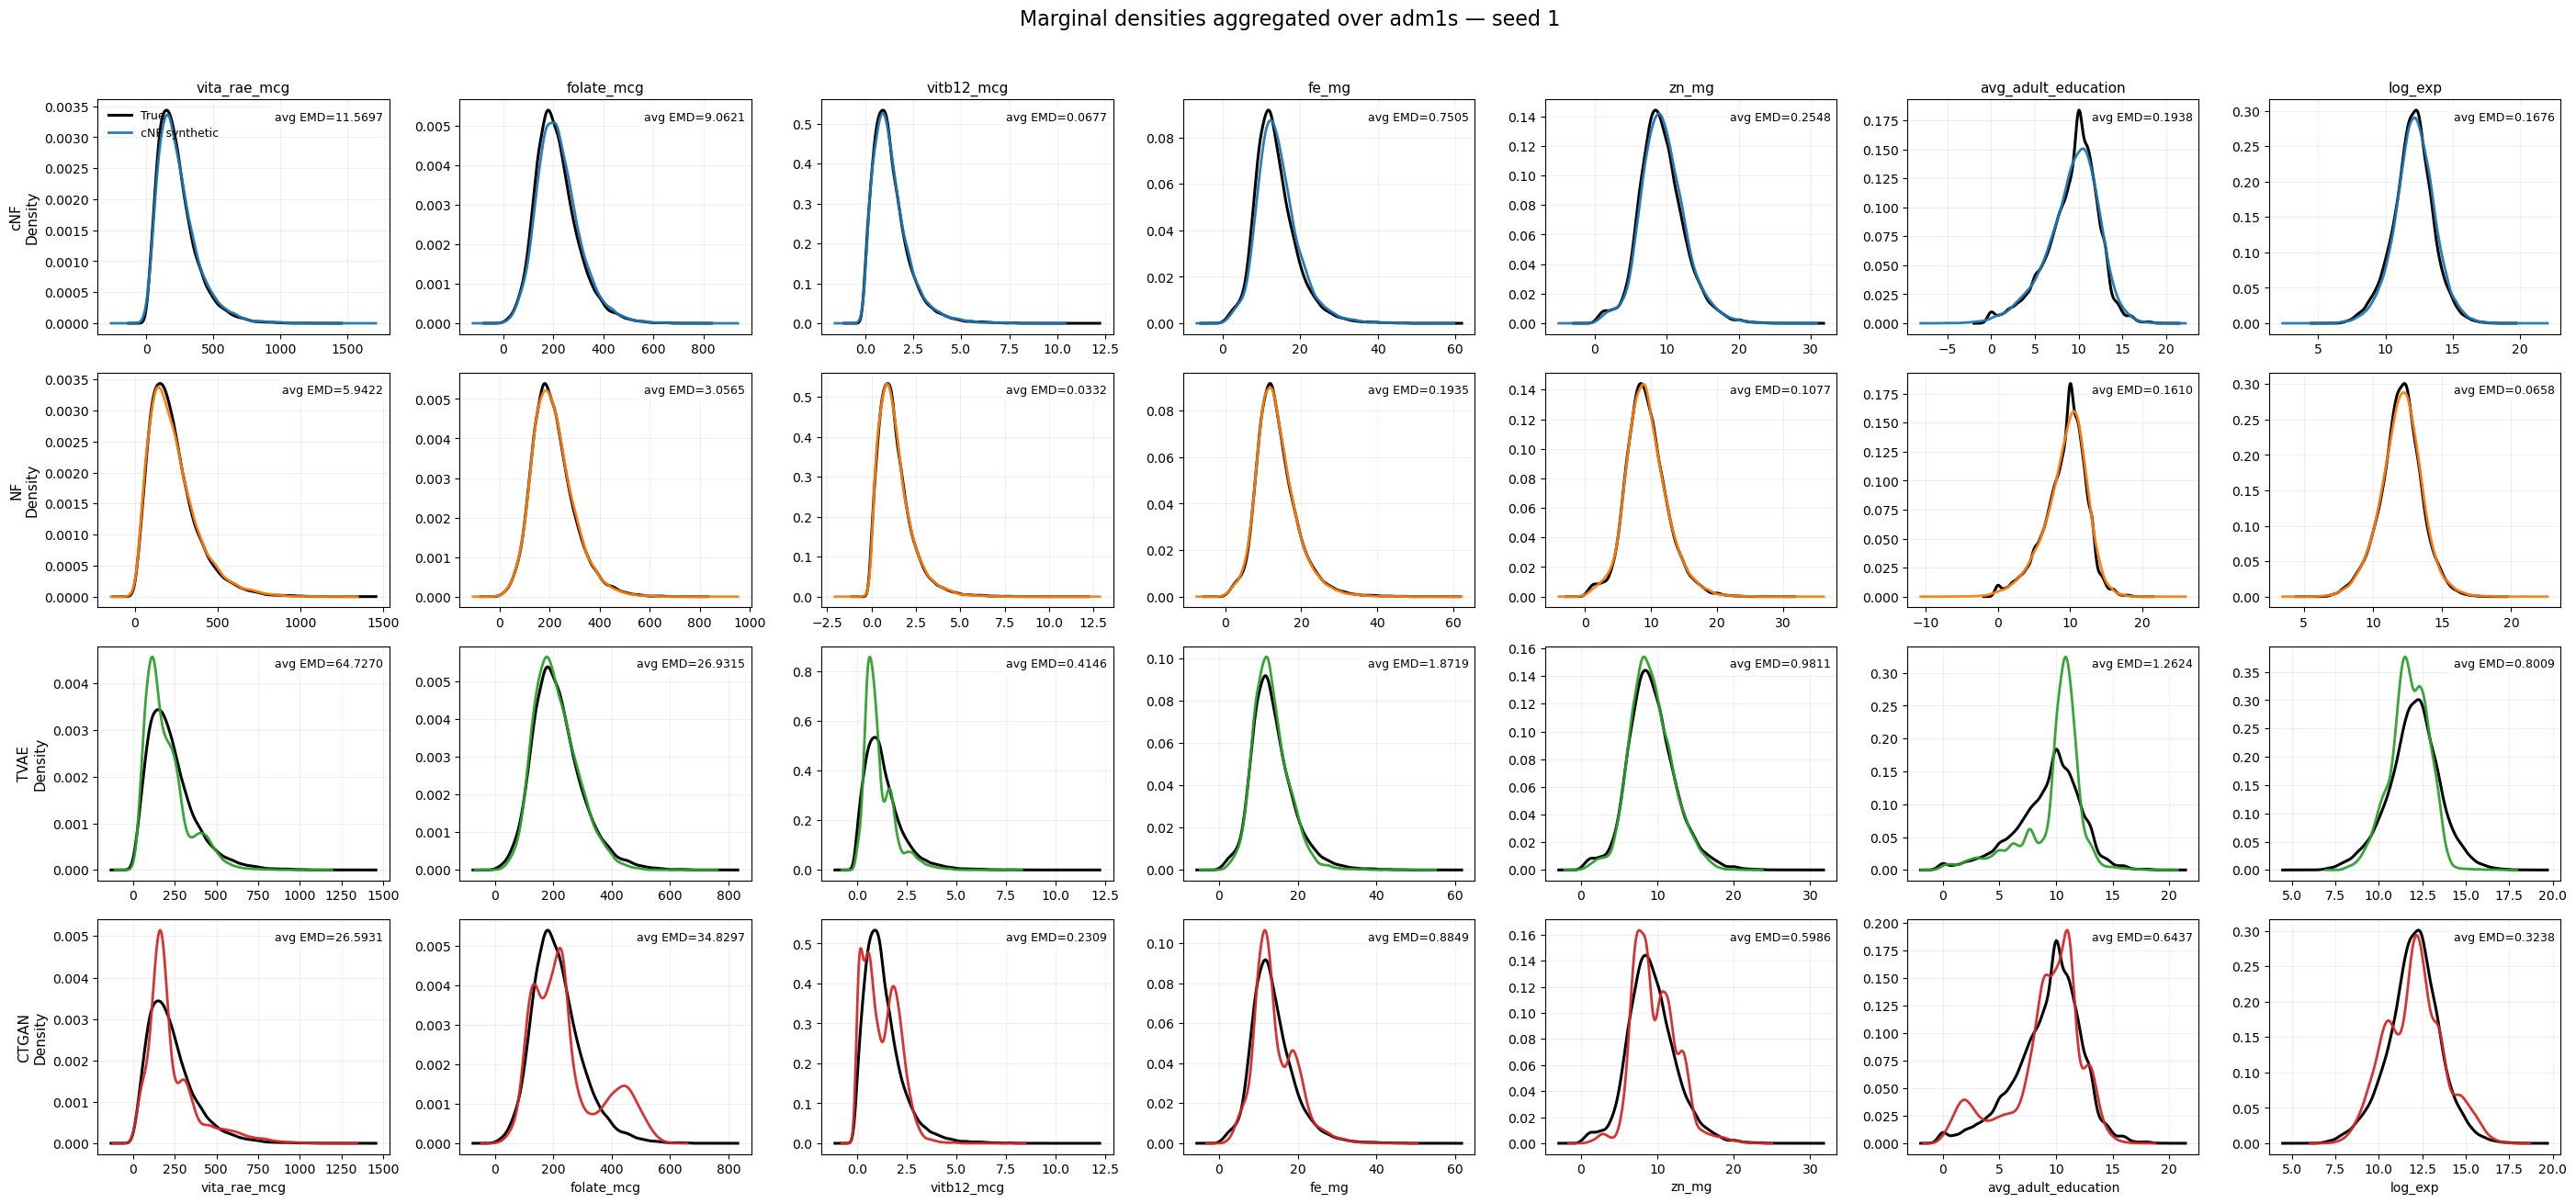

In [17]:
n_models = len(MODELS)
n_vars = len(TARGET_COLS)

fig, axes = plt.subplots(
    nrows=n_models,
    ncols=n_vars,
    figsize=(4 * n_vars, 3.2 * n_models),
    squeeze=False
)

for i, model in enumerate(MODELS):
    real_df, syn_df = load_real_and_synth(model=model, seed=SEED_TO_PLOT)

    for j, var in enumerate(TARGET_COLS):
        ax = axes[i, j]

        real_vals = real_df[var].dropna().astype(float).to_numpy()
        syn_vals = syn_df[var].dropna().astype(float).to_numpy()

        # Plot true in black
        plot_density(
            ax=ax,
            values=real_vals,
            color="black",
            label="True",
            lw=2.2,
            alpha=1.0
        )

        # Plot synthetic in model-specific color
        plot_density(
            ax=ax,
            values=syn_vals,
            color=MODEL_COLORS.get(model, "tab:blue"),
            label=f"{model} synthetic",
            lw=2.0,
            alpha=0.95
        )

        # Average EMD over adm1
        emd_match = emd_avg_seed.loc[
            (emd_avg_seed["model"] == model) &
            (emd_avg_seed["variable"] == var),
            "avg_emd_over_adm1"
        ]

        avg_emd = emd_match.iloc[0] if len(emd_match) > 0 else np.nan

        ax.text(
            0.98, 0.95,
            f"avg EMD={avg_emd:.4f}" if pd.notna(avg_emd) else "avg EMD=NA",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=9,
            bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
        )

        if i == 0:
            ax.set_title(var, fontsize=11)

        if j == 0:
            ax.set_ylabel(f"{model}\nDensity", fontsize=11)
        else:
            ax.set_ylabel("")

        if i == n_models - 1:
            ax.set_xlabel(var, fontsize=10)
        else:
            ax.set_xlabel("")

        ax.grid(alpha=0.2)

        if i == 0 and j == 0:
            ax.legend(frameon=False, fontsize=9, loc="upper left")

plt.suptitle(f"Marginal densities aggregated over adm1s — seed {SEED_TO_PLOT}", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

## Baselines

Upper bownd marginal fidelity baseline: bootstrap
Lower bound marginal fidelity baseline: global mean 

In [18]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import wasserstein_distance

BASELINE_ROOT = Path("/data/shared/fsibilla/clean_code/Q0/fidelity/baselines/lka_micron/marginal")

EMD_UB_OUT = OUTPUT_DIR / "emd_ub_true.csv"
EMD_LB_OUT = OUTPUT_DIR / "emd_lb_true.csv"

In [19]:
def load_true_data(seed: int, reference_model: str = REFERENCE_REAL_MODEL) -> pd.DataFrame:
    """
    Load the true/training dataset for the given seed from a reference model folder.
    """
    real_path = (
        EXPERIMENTS_ROOT
        / reference_model
        / DATASET_NAME
        / "results"
        / f"seed_{seed}"
        / REAL_FILENAME_TEMPLATE.format(seed=seed)
    )

    if not real_path.exists():
        raise FileNotFoundError(f"True dataset not found: {real_path}")

    df = pd.read_csv(real_path)

    required_cols = TARGET_COLS + [ADM1_COL]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in true dataset for seed {seed}: {missing}")

    df = df[required_cols].copy()
    df[ADM1_COL] = df[ADM1_COL].astype(str)

    for col in TARGET_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

In [20]:
def load_baseline_data(seed: int, baseline_name: str) -> pd.DataFrame:
    """
    Load one baseline dataset for a given seed.
    baseline_name must be 'UB' or 'LB'.
    """
    if baseline_name not in {"UB", "LB"}:
        raise ValueError("baseline_name must be 'UB' or 'LB'")

    path = BASELINE_ROOT / f"seed_{seed}" / f"{baseline_name}.csv"

    if not path.exists():
        raise FileNotFoundError(f"Baseline file not found: {path}")

    df = pd.read_csv(path)

    required_cols = TARGET_COLS + [ADM1_COL]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in baseline {baseline_name}, seed {seed}: {missing}")

    df = df[required_cols].copy()
    df[ADM1_COL] = df[ADM1_COL].astype(str)

    for col in TARGET_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

In [21]:
def compute_emd_by_adm1(real_df: pd.DataFrame, gen_df: pd.DataFrame, seed: int, model_name: str):
    """
    Compute unscaled EMD (Wasserstein-1 distance) between real and generated
    marginals for each variable, separately within each adm1.

    Returns a dataframe with columns:
    model, seed, adm1, variable, emd_distance
    """
    results = []

    all_adm1 = sorted(
        set(real_df[ADM1_COL].dropna().unique()).intersection(
            set(gen_df[ADM1_COL].dropna().unique())
        )
    )

    for adm1 in all_adm1:
        real_adm = real_df.loc[real_df[ADM1_COL] == adm1]
        gen_adm = gen_df.loc[gen_df[ADM1_COL] == adm1]

        for var in TARGET_COLS:
            x_real = real_adm[var].dropna().to_numpy()
            x_gen = gen_adm[var].dropna().to_numpy()

            if len(x_real) == 0 or len(x_gen) == 0:
                emd = np.nan
            else:
                emd = wasserstein_distance(x_real, x_gen)

            results.append({
                "model": model_name,
                "seed": seed,
                "adm1": adm1,
                "variable": var,
                "emd_distance": emd
            })

    return pd.DataFrame(results)

In [22]:
all_ub_results = []

for seed in SEEDS:
    print(f"Processing UB, seed={seed} ...")
    real_df = load_true_data(seed=seed)
    ub_df = load_baseline_data(seed=seed, baseline_name="UB")

    ub_emd_df = compute_emd_by_adm1(
        real_df=real_df,
        gen_df=ub_df,
        seed=seed,
        model_name="UB"
    )
    all_ub_results.append(ub_emd_df)

emd_ub_true = pd.concat(all_ub_results, ignore_index=True)

print("Done UB.")
print("Rows:", len(emd_ub_true))
emd_ub_true.head()

Processing UB, seed=1 ...
Processing UB, seed=2 ...
Processing UB, seed=3 ...
Processing UB, seed=4 ...
Processing UB, seed=5 ...
Done UB.
Rows: 315


,model,seed,adm1,variable,emd_distance
0,UB,1,Central,vita_rae_mcg,4.353508
1,UB,1,Central,folate_mcg,1.767684
2,UB,1,Central,vitb12_mcg,0.018204
3,UB,1,Central,fe_mg,0.100699
4,UB,1,Central,zn_mg,0.070898


In [23]:
all_lb_results = []

for seed in SEEDS:
    print(f"Processing LB, seed={seed} ...")
    real_df = load_true_data(seed=seed)
    lb_df = load_baseline_data(seed=seed, baseline_name="LB")

    lb_emd_df = compute_emd_by_adm1(
        real_df=real_df,
        gen_df=lb_df,
        seed=seed,
        model_name="LB"
    )
    all_lb_results.append(lb_emd_df)

emd_lb_true = pd.concat(all_lb_results, ignore_index=True)

print("Done LB.")
print("Rows:", len(emd_lb_true))
emd_lb_true.head()

Processing LB, seed=1 ...
Processing LB, seed=2 ...
Processing LB, seed=3 ...
Processing LB, seed=4 ...
Processing LB, seed=5 ...
Done LB.
Rows: 315


,model,seed,adm1,variable,emd_distance
0,LB,1,Central,vita_rae_mcg,108.233373
1,LB,1,Central,folate_mcg,67.248528
2,LB,1,Central,vitb12_mcg,0.653287
3,LB,1,Central,fe_mg,3.959306
4,LB,1,Central,zn_mg,2.418333


In [24]:
emd_ub_true.to_csv(EMD_UB_OUT, index=False)
emd_lb_true.to_csv(EMD_LB_OUT, index=False)

print(f"Saved UB EMD table to: {EMD_UB_OUT}")
print(f"Saved LB EMD table to: {EMD_LB_OUT}")

Saved UB EMD table to: /data/shared/fsibilla/clean_code/Q0/fidelity/lka_micron/emd_ub_true.csv
Saved LB EMD table to: /data/shared/fsibilla/clean_code/Q0/fidelity/lka_micron/emd_lb_true.csv


## Normalize between baselines and visualize results

In [25]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
FIDELITY_DIR = Path("/data/shared/fsibilla/clean_code/Q0/fidelity/lka_micron")

GEN_EMD_PATH = FIDELITY_DIR / "emd_gen_true.csv"
UB_EMD_PATH = FIDELITY_DIR / "emd_ub_true.csv"
LB_EMD_PATH = FIDELITY_DIR / "emd_lb_true.csv"

NORMALIZED_OUT_PATH = FIDELITY_DIR / "emd_gen_true_normalized.csv"

In [27]:
gen_emd = pd.read_csv(GEN_EMD_PATH)
ub_emd = pd.read_csv(UB_EMD_PATH)
lb_emd = pd.read_csv(LB_EMD_PATH)

print("gen_emd shape:", gen_emd.shape)
print("ub_emd shape:", ub_emd.shape)
print("lb_emd shape:", lb_emd.shape)

display(gen_emd.head())
display(ub_emd.head())
display(lb_emd.head())

gen_emd shape: (1260, 5)
ub_emd shape: (315, 5)
lb_emd shape: (315, 5)


,model,seed,adm1,variable,emd_distance
0,cNF,1,Central,vita_rae_mcg,8.045999
1,cNF,1,Central,folate_mcg,10.974640
2,cNF,1,Central,vitb12_mcg,0.038305
3,cNF,1,Central,fe_mg,0.622114
4,cNF,1,Central,zn_mg,0.367879


,model,seed,adm1,variable,emd_distance
0,UB,1,Central,vita_rae_mcg,4.353508
1,UB,1,Central,folate_mcg,1.767684
2,UB,1,Central,vitb12_mcg,0.018204
3,UB,1,Central,fe_mg,0.100699
4,UB,1,Central,zn_mg,0.070898


,model,seed,adm1,variable,emd_distance
0,LB,1,Central,vita_rae_mcg,108.233373
1,LB,1,Central,folate_mcg,67.248528
2,LB,1,Central,vitb12_mcg,0.653287
3,LB,1,Central,fe_mg,3.959306
4,LB,1,Central,zn_mg,2.418333


In [28]:
ub_for_merge = (
    ub_emd[["seed", "adm1", "variable", "emd_distance"]]
    .rename(columns={"emd_distance": "emd_ub"})
    .copy()
)

lb_for_merge = (
    lb_emd[["seed", "adm1", "variable", "emd_distance"]]
    .rename(columns={"emd_distance": "emd_lb"})
    .copy()
)

In [29]:
emd_norm = (
    gen_emd
    .merge(ub_for_merge, on=["seed", "adm1", "variable"], how="left")
    .merge(lb_for_merge, on=["seed", "adm1", "variable"], how="left")
    .copy()
)

# denominator
emd_norm["denom"] = emd_norm["emd_lb"] - emd_norm["emd_ub"]

# raw normalized value:
# 0 = UB, 1 = LB
emd_norm["emd_norm_raw"] = np.where(
    emd_norm["denom"].abs() > 1e-12,
    (emd_norm["emd_distance"] - emd_norm["emd_ub"]) / emd_norm["denom"],
    np.nan
)

# clipped version for visualization in [0, 1]
emd_norm["emd_norm"] = emd_norm["emd_norm_raw"].clip(0, 1)

print("Merged shape:", emd_norm.shape)
emd_norm.head()

Merged shape: (1260, 10)


,model,seed,adm1,variable,emd_distance,emd_ub,emd_lb,denom,emd_norm_raw,emd_norm
0,cNF,1,Central,vita_rae_mcg,8.045999,4.353508,108.233373,103.879865,0.035546,0.035546
1,cNF,1,Central,folate_mcg,10.974640,1.767684,67.248528,65.480844,0.140605,0.140605
2,cNF,1,Central,vitb12_mcg,0.038305,0.018204,0.653287,0.635083,0.031652,0.031652
3,cNF,1,Central,fe_mg,0.622114,0.100699,3.959306,3.858607,0.135130,0.135130
4,cNF,1,Central,zn_mg,0.367879,0.070898,2.418333,2.347435,0.126513,0.126513


In [30]:
emd_norm.to_csv(NORMALIZED_OUT_PATH, index=False)
print(f"Saved normalized table to: {NORMALIZED_OUT_PATH}")

Saved normalized table to: /data/shared/fsibilla/clean_code/Q0/fidelity/lka_micron/emd_gen_true_normalized.csv


In [31]:
plot_df = (
    emd_norm
    .groupby(["model", "variable", "adm1"], as_index=False)
    .agg(
        emd_norm_mean=("emd_norm", "mean"),
        emd_norm_std=("emd_norm", "std"),
        n_seeds=("emd_norm", "count")
    )
)

# std can be NaN if only one seed is present
plot_df["emd_norm_std"] = plot_df["emd_norm_std"].fillna(0.0)

print(plot_df.shape)
plot_df.head()

(252, 6)


,model,variable,adm1,emd_norm_mean,emd_norm_std,n_seeds
0,CTGAN,avg_adult_education,Central,0.273964,0.132646,5
1,CTGAN,avg_adult_education,Eastern,0.295884,0.159065,5
2,CTGAN,avg_adult_education,North Central,0.234587,0.152980,5
3,CTGAN,avg_adult_education,North Western,0.254115,0.221926,5
4,CTGAN,avg_adult_education,Northern,0.382857,0.149376,5


In [32]:
MODEL_COLORS = {
    "cNF": "tab:blue",
    "NF": "tab:orange",
    "TVAE": "tab:green",
    "CTGAN": "tab:red",
}

In [34]:
MODEL_ORDER = ["cNF", "NF", "TVAE", "CTGAN"]
MODEL_ORDER = [m for m in MODEL_ORDER if m in plot_df["model"].unique()]

VARIABLE_ORDER = [
    'vita_rae_mcg',
    'folate_mcg', 'vitb12_mcg', 'fe_mg', 'zn_mg',
    'avg_adult_education', 'log_exp'
]
VARIABLE_ORDER = [v for v in VARIABLE_ORDER if v in plot_df["variable"].unique()]

print("Models:", MODEL_ORDER)
print("Variables:", VARIABLE_ORDER)

Models: ['cNF', 'NF', 'TVAE', 'CTGAN']
Variables: ['vita_rae_mcg', 'folate_mcg', 'vitb12_mcg', 'fe_mg', 'zn_mg', 'avg_adult_education', 'log_exp']


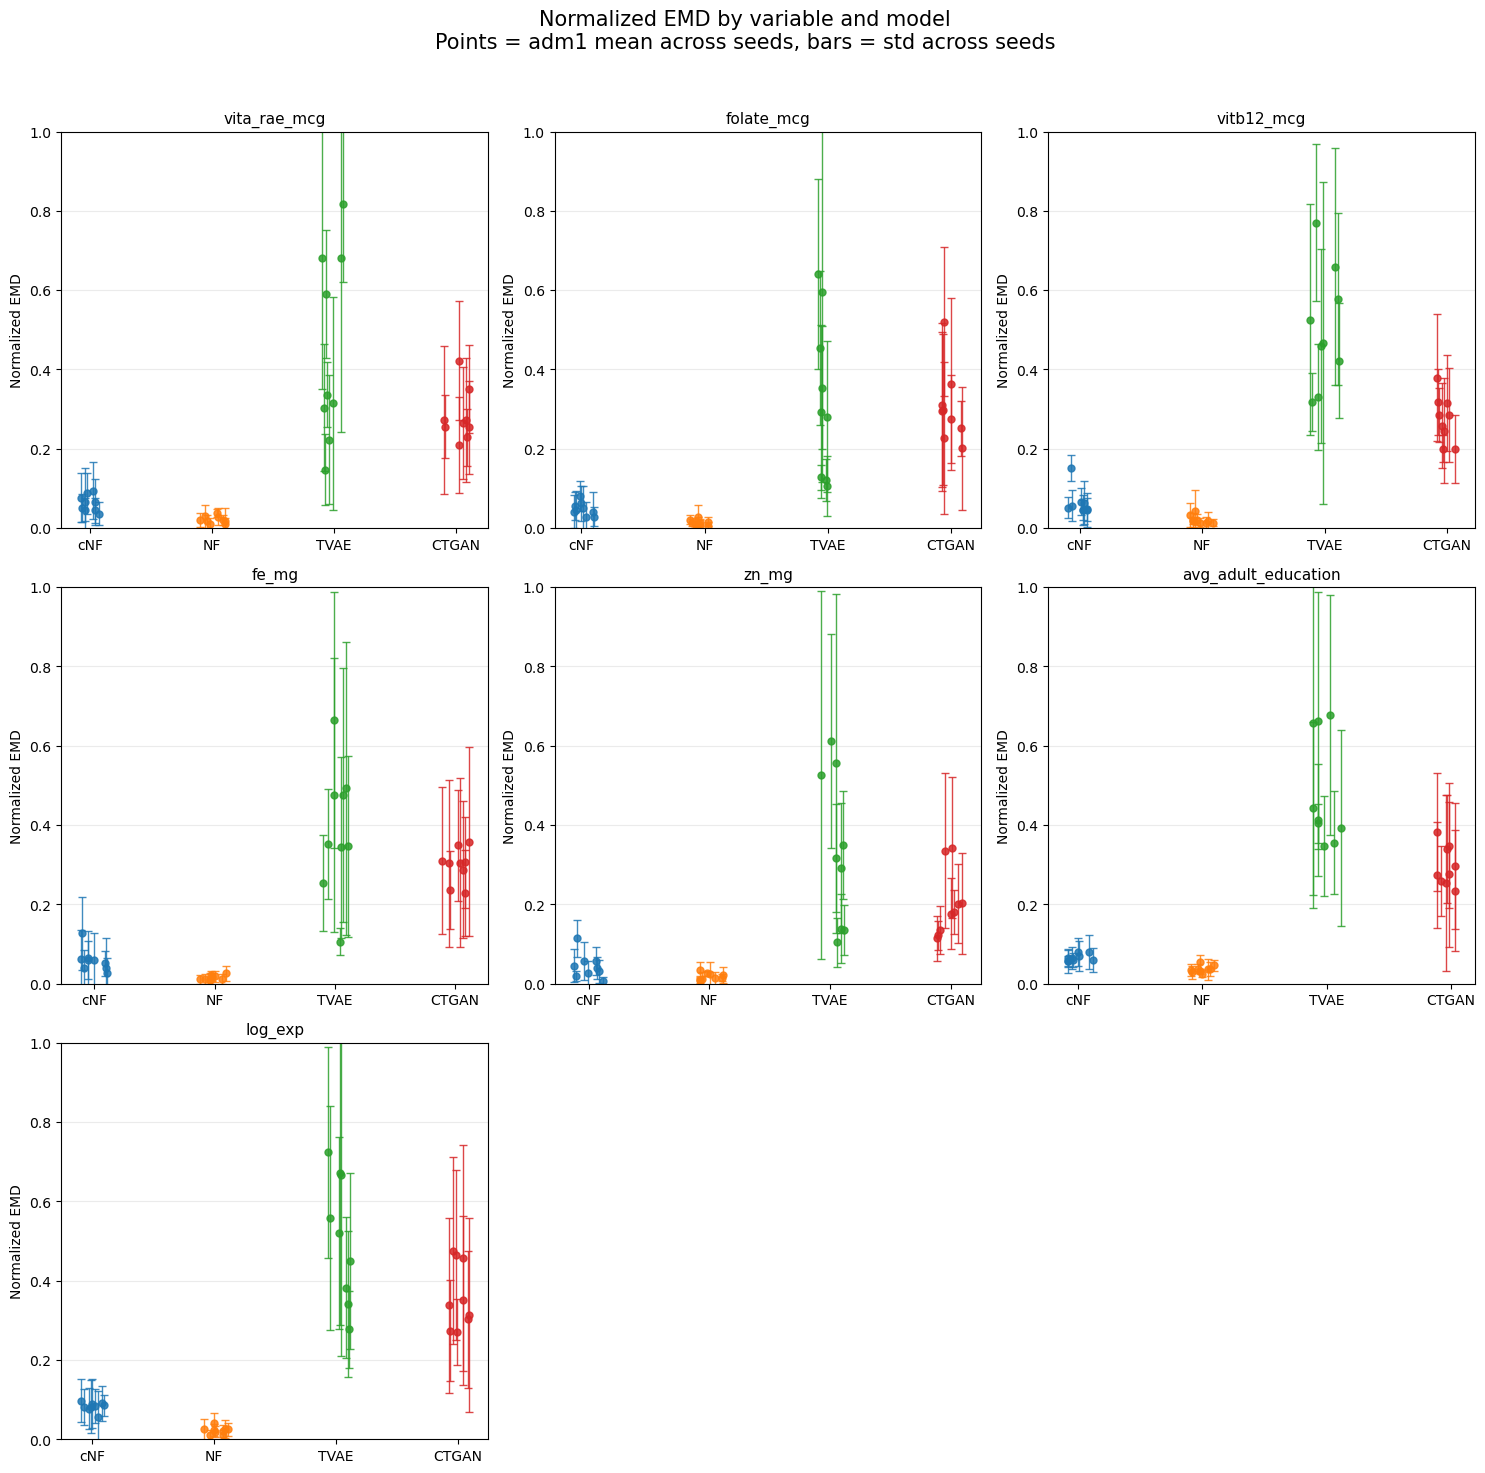

In [35]:
n_vars = len(VARIABLE_ORDER)
ncols = 3
nrows = int(np.ceil(n_vars / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5.0 * ncols, 4.8 * nrows),
    squeeze=False
)

rng = np.random.default_rng(12345)

for idx, var in enumerate(VARIABLE_ORDER):
    r = idx // ncols
    c = idx % ncols
    ax = axes[r, c]

    sub = plot_df.loc[plot_df["variable"] == var].copy()

    for x_pos, model in enumerate(MODEL_ORDER):
        sub_m = sub.loc[sub["model"] == model].copy().sort_values("adm1")

        if sub_m.empty:
            continue

        # small horizontal jitter so multiple adm1 points are visible inside each model column
        jitter = rng.uniform(-0.12, 0.12, size=len(sub_m))
        x_vals = x_pos + jitter

        ax.errorbar(
            x_vals,
            sub_m["emd_norm_mean"].to_numpy(),
            yerr=sub_m["emd_norm_std"].to_numpy(),
            fmt="o",
            capsize=3,
            alpha=0.85,
            color=MODEL_COLORS.get(model, "tab:blue"),
            ecolor=MODEL_COLORS.get(model, "tab:blue"),
            markersize=5,
            linewidth=1
        )

    ax.set_title(var, fontsize=11)
    ax.set_xticks(range(len(MODEL_ORDER)))
    ax.set_xticklabels(MODEL_ORDER, rotation=0)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Normalized EMD")
    ax.grid(alpha=0.25, axis="y")

# hide empty panels
for idx in range(n_vars, nrows * ncols):
    r = idx // ncols
    c = idx % ncols
    axes[r, c].axis("off")

plt.suptitle("Normalized EMD by variable and model\nPoints = adm1 mean across seeds, bars = std across seeds", y=1.02, fontsize=15)
plt.tight_layout()
plt.show()